# 03 — Map Data Comparison: Overture Maps vs OpenStreetMap

Compares the two spatial datasets for Eixample:
- **Overture Maps** (`eixample_overture.duckdb`) — current system
- **OpenStreetMap** (`eixample_osm.duckdb`)

**Metrics**:
- POI count by category (coverage)
- Walk-edge and node count (network completeness)
- Query latency (same query on each)
- Attribute richness (avg non-null columns per POI)
- Agent amenity encounter rate (simulated 100 steps)

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

sns.set_theme(style='whitegrid', palette='muted')

OVERTURE_DB = '../eixample_overture.duckdb'
OSM_DB = '../Backend/Environment/eixample_osm.duckdb'

def query_db(db_path, query, load_spatial=True):
    con = duckdb.connect(db_path, read_only=True)
    if load_spatial:
        con.execute('LOAD spatial')
    result = con.execute(query).fetchdf()
    con.close()
    return result

In [2]:
# POI coverage by category
POI_QUERY = 'SELECT amenity, COUNT(*) as count FROM amenities GROUP BY amenity ORDER BY count DESC LIMIT 20'

overture_pois = query_db(OVERTURE_DB, POI_QUERY)
osm_pois = query_db(OSM_DB, POI_QUERY)

print('Overture POI types:', len(overture_pois), ' total POIs:', overture_pois['count'].sum())
print('OSM POI types:', len(osm_pois), ' total POIs:', osm_pois['count'].sum())

Overture POI types: 20  total POIs: 11051
OSM POI types: 20  total POIs: 10064


In [3]:
# Network completeness
NET_QUERY = 'SELECT COUNT(*) as edges FROM walk_edges'

try:
    overture_edges = query_db(OVERTURE_DB, NET_QUERY)['edges'].iloc[0]
except Exception:
    overture_edges = 0
try:
    osm_edges = query_db(OSM_DB, NET_QUERY)['edges'].iloc[0]
except Exception:
    osm_edges = 0

print(f'Overture walk edges: {overture_edges}')
print(f'OSM walk edges: {osm_edges}')

Overture walk edges: 7795
OSM walk edges: 24112


In [4]:
# Query latency comparison (20 runs)
LATENCY_QUERY = "SELECT name, amenity, ST_Distance(geometry, ST_GeomFromText('POINT (2.1686 41.3954)')) as d FROM amenities WHERE ST_DWithin(geometry, ST_GeomFromText('POINT (2.1686 41.3954)'), 0.001) ORDER BY d LIMIT 10"

def bench_db_latency(db_path, query, runs=20):
    times = []
    con = duckdb.connect(db_path, read_only=True)
    con.execute('LOAD spatial')
    for _ in range(runs):
        t0 = time.perf_counter()
        con.execute(query).fetchall()
        times.append((time.perf_counter() - t0) * 1000)
    con.close()
    return times

overture_times = bench_db_latency(OVERTURE_DB, LATENCY_QUERY)
osm_times = bench_db_latency(OSM_DB, LATENCY_QUERY)
print(f'Overture median latency: {pd.Series(overture_times).median():.2f}ms')
print(f'OSM median latency: {pd.Series(osm_times).median():.2f}ms')

Overture median latency: 2.98ms
OSM median latency: 1.90ms


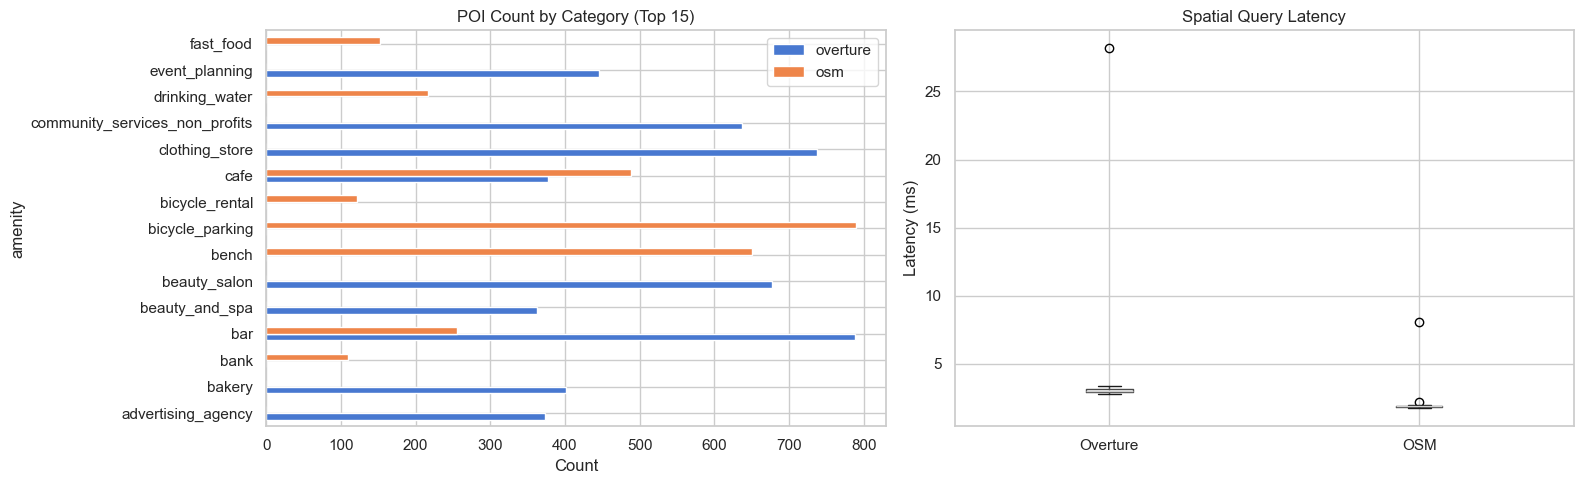

In [5]:
# Visualise POI coverage comparison
merged = overture_pois.rename(columns={'count': 'overture'}).merge(
    osm_pois.rename(columns={'count': 'osm'}), on='amenity', how='outer'
).fillna(0).set_index('amenity')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

merged.head(15).plot(kind='barh', ax=axes[0])
axes[0].set_title('POI Count by Category (Top 15)')
axes[0].set_xlabel('Count')

# Latency box plot
lat_df = pd.DataFrame({'Overture': overture_times, 'OSM': osm_times})
lat_df.boxplot(ax=axes[1])
axes[1].set_title('Spatial Query Latency')
axes[1].set_ylabel('Latency (ms)')

plt.tight_layout()
plt.savefig('results_03_map_comparison.png', dpi=150)
plt.show()